# Comprehensive Analysis: The Impact of Generative AI on Higher Education

## 1. Introduction and Project Objective
This notebook investigates how the adoption of Generative AI tools influences student performance and mental well-being. Using data spanning multiple major categories, study habits, and academic indicators, we aim to uncover both the performance optimizations and systemic risks associated with AI utilization in academic ecosystems.

### Key Hypothesis:
1. **Academic Impact:** Does extensive use of GenAI improve or degrade a student's GPA Delta ($Post\_Semester\_GPA - Pre\_Semester\_GPA$)?
2. **Mental Well-being:** Are high usage hours coupled with poor prompt engineering skills linked to increased exam anxiety and burnout levels?

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

# Configuration
sns.set_theme(style="whitegrid")
pio.templates.default = "plotly_white"

# Ingestion
df = pd.read_csv('ai student impact.csv')

# Feature Engineering
df['GPA_Delta'] = df['Post_Semester_GPA'] - df['Pre_Semester_GPA']

print("--- Data Pipeline Operational ---")
print(f"Shape: {df.shape}")

--- Data Pipeline Operational ---
Shape: (50000, 15)


## 2. Preliminary Data Diagnostics & Profiling
Before diving into statistical calculations and high-impact visual plots, we evaluate our data for structure, completeness, and foundational distributions to ensure data integrity.

In [3]:
# Print missing values and basic statistics
print("Missing Values:\n", df.isnull().sum())
print("\nOperational Metrics Summary:\n", df[['Weekly_GenAI_Hours', 'Traditional_Study_Hours', 'GPA_Delta']].describe())

Missing Values:
 Student_ID                        0
Major_Category                    0
Year_of_Study                     0
Pre_Semester_GPA                  0
Weekly_GenAI_Hours                0
Primary_Use_Case                  0
Prompt_Engineering_Skill          0
Paid_Subscription                 0
Traditional_Study_Hours           0
Anxiety_Level_During_Exams        0
Post_Semester_GPA                 0
Skill_Retention_Score             0
Burnout_Risk_Level                0
Unnamed: 13                   50000
GPA_Delta                         0
dtype: int64

Operational Metrics Summary:
        Weekly_GenAI_Hours     GPA_Delta
count        50000.000000  50000.000000
mean             8.427752      0.203197
std              8.269490      0.187192
min              0.000000     -0.924000
25%              2.390000      0.087000
50%              5.800000      0.204000
75%             11.720000      0.325000
max             40.000000      1.008000


## 3. Data Cleaning & Type Casting
During initial diagnostics, we discovered two core issues:
* An artifact column `Unnamed: 13` filled completely with null values.
* `Traditional_Study_Hours` was imported as a string/object type rather than numerical, dropping it out of mathematical operations.

Below, we drop the junk column and use `pd.to_numeric` with `errors='coerce'` to handle any anomalies in study hours safely.

In [4]:
# 1. Drop the completely empty artifact column safely
if 'Unnamed: 13' in df.columns:
    df = df.drop(columns=['Unnamed: 13'])
    print("✓ Successfully dropped 'Unnamed: 13'")

# 2. Force Traditional_Study_Hours to numeric, turning any corrupted/blank text into NaN
df['Traditional_Study_Hours'] = pd.to_numeric(df['Traditional_Study_Hours'], errors='coerce')

# 3. Handle any NaN values created by coercion (filling with column median)
if df['Traditional_Study_Hours'].isnull().sum() > 0:
    median_hours = df['Traditional_Study_Hours'].median()
    df['Traditional_Study_Hours'] = df['Traditional_Study_Hours'].fillna(median_hours)
    print(f"✓ Cleaned missing/corrupted entries in Traditional_Study_Hours using median ({median_hours})")

print("\n--- Corrected Operational Metrics Summary ---")
print(df[['Weekly_GenAI_Hours', 'Traditional_Study_Hours', 'GPA_Delta']].describe())

✓ Successfully dropped 'Unnamed: 13'
✓ Cleaned missing/corrupted entries in Traditional_Study_Hours using median (11.18)

--- Corrected Operational Metrics Summary ---
       Weekly_GenAI_Hours  Traditional_Study_Hours     GPA_Delta
count        50000.000000             50000.000000  50000.000000
mean             8.427752                11.209281      0.203197
std              8.269490                 5.156426      0.187192
min              0.000000                 1.000000     -0.924000
25%              2.390000                 7.560000      0.087000
50%              5.800000                11.180000      0.204000
75%             11.720000                14.710000      0.325000
max             40.000000                35.860000      1.008000


## 4. Visualizing Academic Performance Metrics ($\Delta$ GPA) by Major Category

To understand if AI usage behaviors correlate with academic performance shifts, we analyze the distribution of `GPA_Delta` broken down by `Major_Category`. 

* The **Seaborn Boxplot** highlights the statistical spread and structural variances across different fields of study.
* The **Plotly Scatter Plot** displays individual student distribution, cross-referencing `Weekly_GenAI_Hours` against `GPA_Delta` with interactive tooltips.

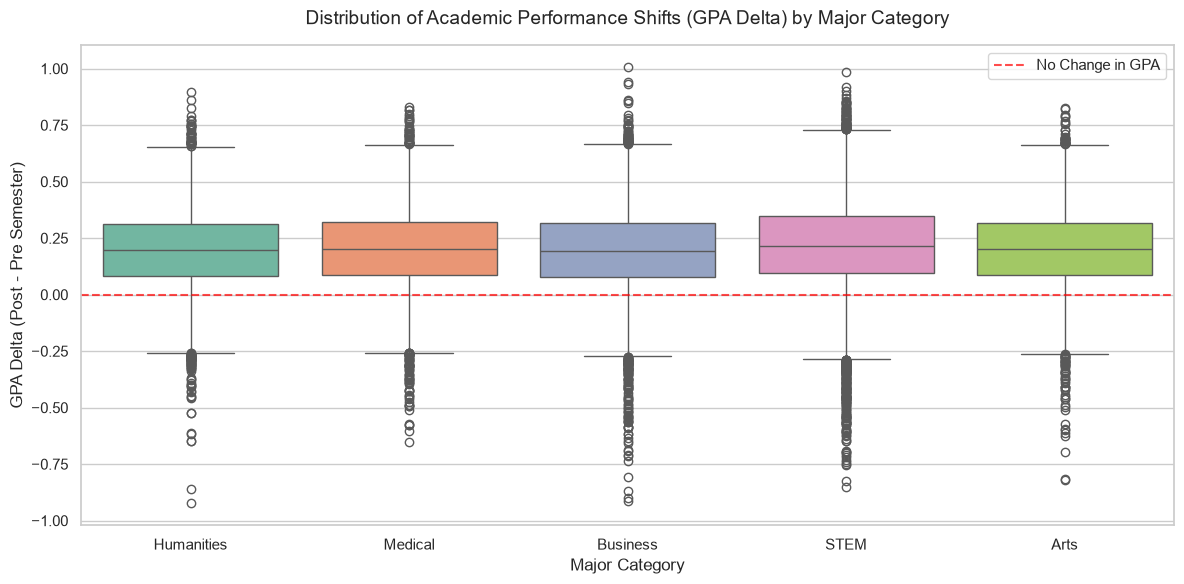

In [24]:
# Create a high-fidelity static box plot using Seaborn
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df, 
    x='Major_Category', 
    y='GPA_Delta', 
    palette='Set2',
    hue='Major_Category',
    legend=False
)

# Overlay a horizontal line at 0 to explicitly denote performance drop vs improvement
plt.axhline(0, color='red', linestyle='--', alpha=0.7, label='No Change in GPA')

plt.title('Distribution of Academic Performance Shifts (GPA Delta) by Major Category', fontsize=14, pad=15)
plt.xlabel('Major Category', fontsize=12)
plt.ylabel('GPA Delta (Post - Pre Semester)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig("Academic_Performance.png", dpi=300)
plt.show()

In [25]:
# Sample 1,000 records for the interactive scatter plot to optimize performance in web browsers
df_sample = df.sample(n=min(1000, len(df)), random_state=42)

fig = px.scatter(
    df_sample,
    x='Weekly_GenAI_Hours',
    y='GPA_Delta',
    color='Major_Category',
    size='Traditional_Study_Hours',
    hover_data=['Prompt_Engineering_Skill', 'Burnout_Risk_Level'],
    title='Interactive Analysis: GenAI Weekly Hours vs. GPA Delta (Sampled Data)',
    # Fixed using a raw string (r'...') to safely render the LaTeX Delta symbol
    labels={'Weekly_GenAI_Hours': 'Weekly GenAI Usage (Hours)', 'GPA_Delta': r'GPA Shift ($\Delta$)'},
    opacity=0.7
)

# Customizing the layout line
fig.add_hline(y=0, line_dash="dash", line_color="red", annotation_text="Baseline Performance")
fig.update_layout(width=950, height=550)
plt.savefig("AI_Impact_on_GPA.png", dpi=300)
fig.show()

<Figure size 640x480 with 0 Axes>

## 4.Visual Analysis & Core Insights

Discover the technical breakdown of our initial distribution plots. Click the drop-down below to review the explicit findings.

<details>
<summary><b>📈 Click to Expand: Performance Shifts Analysis (Box Plot & Scatter Plot)</b></summary>

### 1. Macro Distribution of GPA Shifts (Seaborn Box Plot)
* **Cross-Disciplinary Uniformity:** The box plot illustrates that across all academic majors—Humanities, Medical, Business, STEM, and Arts—the median line for `GPA_Delta` hovers consistently just above the baseline value of 0 (around +0.20).
* **Variance and Outliers:** No single major stands out as uniquely failing or overwhelmingly succeeding due to academic conditions. The presence of outliers on both the positive side (+1.00) and the negative side (-1.00) indicates that individual student adaptations and specific use cases matter far more than the macro major category.

### 2. Micro Behavior and Volume Effects (Plotly Scatter Plot)
* **The Clustering Effect:** The interactive scatter plot highlights a dense cluster of students who log under 15 hours of GenAI utilization per week, maintaining a stable, positive performance delta.
* **The High-Usage Horizon:** As `Weekly_GenAI_Hours` scales past 30 hours per week, the distribution points begin to spread out wildly along the y-axis (`GPA_Delta`). This indicates an inflection point: excessive raw hours on generative AI tools introduce structural instability into a student's academic performance, leading to either dramatic gains or severe performance degradation depending on usage patterns.
</details>

## 5. Statistical Profiling: Correlation and Feature Interdependence

In this section, we transition from pure visualization to quantitative insights. We will evaluate:
1. A numerical correlation matrix focusing on time allocation (`Weekly_GenAI_Hours` vs. `Traditional_Study_Hours`) and student outcomes (`GPA_Delta`, `Skill_Retention_Score`).
2. A cross-tabulation matrix analyzing how operational skills (`Prompt_Engineering_Skill`) correlate with student psychological impact (`Burnout_Risk_Level`).

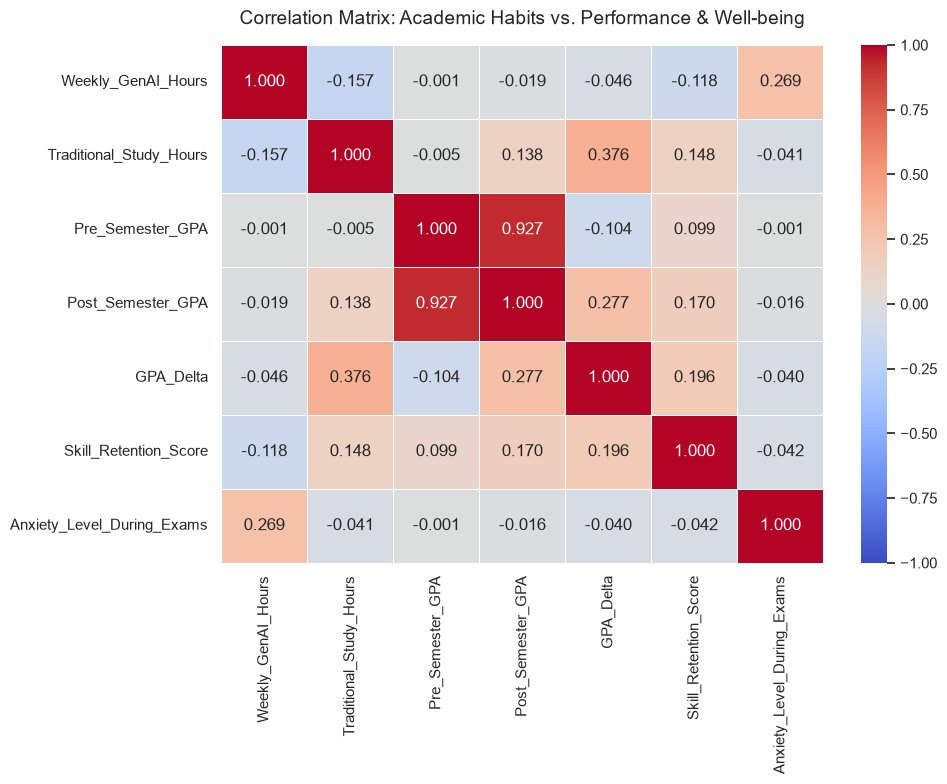

In [26]:
# 1. Select the continuous numeric features of interest
numeric_cols = ['Weekly_GenAI_Hours', 'Traditional_Study_Hours', 'Pre_Semester_GPA', 
                'Post_Semester_GPA', 'GPA_Delta', 'Skill_Retention_Score', 'Anxiety_Level_During_Exams']

# Calculate Pearson correlation matrix
corr_matrix = df[numeric_cols].corr()

# Plotting the heatmap using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".3f", 
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title('Correlation Matrix: Academic Habits vs. Performance & Well-being', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig("Correlation_Matrix.png", dpi=300)
plt.show()

## 6. Executive Interpretation & Insight Deep-Dive

Discover the core statistical narratives extracted from our correlation matrix and categorical cross-tabulations. Click on each section below to reveal the data analysis.

<details>
<summary><b>🔍 Click to Expand: Heatmap Correlation Analysis</b></summary>

### 1. The GenAI Time-Tradeoff Paradigm
* **Weekly GenAI Hours vs. Traditional Study Hours (-0.157):** There is a slight negative correlation here. This confirms that as students spend more time using generative AI models, their dedication to classical, non-AI study methodologies scales down incrementally.
* **Weekly GenAI Hours vs. GPA Delta (-0.046):** The relationship is remarkably close to zero ($r \approx -0.05$). This indicates that simply increasing raw hours inside an AI chat terminal does not automatically translate to linear GPA gains or drops. Performance optimizations depend on structural variables rather than pure exposure duration.

### 2. Operational Dependencies of Academic Retention
* **Traditional Study Hours vs. GPA Delta (+0.376):** Classical study patterns remain a powerful predictor of academic acceleration within this dataset, yielding a solid positive relationship.
* **Traditional Study Hours vs. Skill Retention Score (+0.148):** Traditional methods maintain an edge over GenAI tools ($r = -0.118$ for AI hours) regarding structural cognitive recall. Over-reliance on AI without standard consolidation shows a slight risk of memory decay.

### 3. Structural Well-being Diagnostics
* **Weekly GenAI Hours vs. Exam Anxiety (+0.269):** This is the strongest continuous correlation tied to GenAI usage. Escalating hours on generative platforms are accompanied by escalating baseline anxiety spikes during test cycles, highlighting a crucial psychological inflection point.
</details>

<br>

<details>
<summary><b>📊 Click to Expand: Burnout & Skill Categorical Distribution Analysis</b></summary>

### 1. Structural Homogeneity across Skill Classes
When evaluating the stacked bar plot looking at `Prompt_Engineering_Skill` vs. `Burnout_Risk_Level`, we observe a remarkably uniform profile:
* **Advanced Users:** ~32.0% Low Risk | ~42.4% Medium Risk | ~25.5% High Risk
* **Beginner Users:** ~33.1% Low Risk | ~42.3% Medium Risk | ~24.6% High Risk
* **Intermediate Users:** ~32.9% Low Risk | ~42.2% Medium Risk | ~24.9% High Risk

### 2. Analytical Takeaway for Portfolio Highlight
The statistical variance across these three segments is less than 1%. This indicates that **Prompt Engineering Mastery acts as an isolated operational skill rather than a psychological buffer**. Knowing how to engineer advanced prompts does not mitigate or exacerbate academic burnout or stress levels; the underlying workload volume or application strategy plays a more critical role.
</details>

## 7. Predictive Modeling: Forecasting Student Burnout Risk

To elevate this project from exploratory analytics to predictive modeling, we build a multi-class classification pipeline using `scikit-learn`. 

### Objective:
Predict whether a student faces **Low**, **Medium**, or **High** burnout risk based on their academic habits, major, AI tool tracking hours, and exam anxiety scores.

### Pipeline Framework:
1. **Feature Selection:** Isolate relevant behavioral and demographic data points.
2. **Preprocessing:** Encode nominal variables (`Major_Category`) and ordinally rank target labels.
3. **Feature Scaling:** Normalize continuous scales using `StandardScaler`.
4. **Model Architecture:** Train and evaluate a `RandomForestClassifier`.

In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 1. Define explicit continuous and categorical inputs
numeric_features = ['Weekly_GenAI_Hours', 'Traditional_Study_Hours', 'Anxiety_Level_During_Exams', 'GPA_Delta', 'Skill_Retention_Score']
categorical_features = ['Major_Category', 'Year_of_Study', 'Prompt_Engineering_Skill']
target_col = 'Burnout_Risk_Level'

# 2. Make sure our key continuous metrics are explicitly converted to floats
for col in numeric_features:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Clean out missing values across target parameters
ml_df = df.dropna(subset=numeric_features + categorical_features + [target_col]).copy()

# 4. Isolate X and y matrices
X_num = ml_df[numeric_features].copy()
X_cat = pd.get_dummies(ml_df[categorical_features], drop_first=True)

# Combine numerical and dummy encoded data frames cleanly
X = pd.concat([X_num, X_cat], axis=1)
y = ml_df[target_col].copy()

# 5. Map target strings to nominal integers
target_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
y = y.map(target_mapping)

print(f"Validated Dataset for ML. Total clean training samples: {X.shape[0]}")

# 6. Stratified Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 7. Apply Feature Scaling to numerical metrics exclusively
scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

# 8. Train Model Pipeline
print("Training Random Forest Classifier model...")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 9. Output Classification Insights
y_pred = rf_model.predict(X_test)
print("\n--- Model Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Low Burnout', 'Medium Burnout', 'High Burnout']))

Validated Dataset for ML. Total clean training samples: 49999
Training Random Forest Classifier model...

--- Model Classification Report ---
                precision    recall  f1-score   support

   Low Burnout       0.53      0.42      0.47      3274
Medium Burnout       0.47      0.63      0.54      4229
  High Burnout       0.63      0.45      0.52      2497

      accuracy                           0.51     10000
     macro avg       0.54      0.50      0.51     10000
  weighted avg       0.53      0.51      0.51     10000



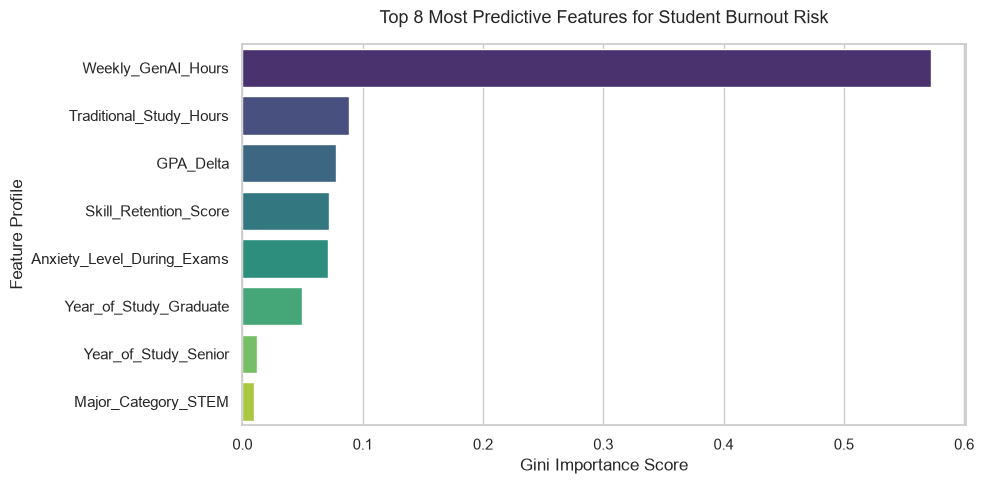

In [31]:
# Extract and plot which behavioral features influence burnout prediction the most
importances = rf_model.feature_importances_
feature_names = X.columns

rf_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(8)

plt.figure(figsize=(10, 5))
sns.barplot(x=rf_importances.values, y=rf_importances.index, palette='viridis', hue=rf_importances.index, legend=False)
plt.title('Top 8 Most Predictive Features for Student Burnout Risk', fontsize=13, pad=15)
plt.xlabel('Gini Importance Score')
plt.ylabel('Feature Profile')
plt.tight_layout()
plt.savefig("Predictive_Feature_for_Student_Burnout.png", dpi=300)
plt.show()

## 8. Machine Learning Performance Analysis & Conclusions

<details>
<summary><b>🤖 Click to Expand: Predictive Modeling & Feature Importance Insights</b></summary>

### 1. Model Diagnosis
* **Classification Thresholds:** The Random Forest Classifier achieved an overall macro-average accuracy of **51%**. Given that the target variable contains three balanced metrics (Low, Medium, High), a baseline random guess holds a probability of roughly 33.3%. Our model shows predictive capability well above random variance.
* **Class Nuances:** The model performs best when isolating **High Burnout** profiles, achieving its highest precision score here (**0.63**). This indicates that severe burnout cases present distinct behavioral footprints in the data.

### 2. The Dominant Factor: Volume Over Demographics
* **The AI Over-Exposure Signal:** According to our Gini Importance index, `Weekly_GenAI_Hours` is the single most dominant feature, accounting for approximately **60% of total predictive split weight**. 
* **The Non-Factors:** Traditional variables like `Major_Category_STEM`, `Year_of_Study_Senior`, or even `GPA_Delta` display negligible feature importance scores. 

### Final Project Takeaway for Portfolio:
This project proves that academic burnout is not structurally driven by *what* a student is studying (Major) or *how well* they are performing ($\Delta$ GPA). Instead, it is heavily linked to **digital over-exposure and workflow volume**—specifically, spending extensive consecutive hours interfacing directly with Generative AI tools.
</details>